### Can a computer learn if we are going to detect gravitational waves? (Part 2)
 In order to decide if a feature in the observed population of objects is telling us something new about reality, we need to understand and model our **selection effects**.

 In observational astronomy, this is known as **Malmquist bias** and was first formulated in 1922.

 The goal here is to learn the **LIGO detectability** using a neural network: can we predict if a gravitational-wave source will be detected?

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
import tensorflow as tf
from tensorflow import keras

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import h5py
import os

In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report

In [5]:
from sklearn.neural_network import MLPClassifier

In [6]:
path = "data_files/"
file_path = os.path.join(path, "sample_2e7_design_precessing_higherordermodes_3detectors.h5")

In [7]:
# Exploring the datafile categories
names = []
with h5py.File(file_path, 'r') as f:
  for key in f.keys():
    names.append(key)

In [8]:
print(names)

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [9]:
# Extrapolating data
data = []
with h5py.File(file_path, 'r') as f:
  for key in names:
    temp_data = f[key][:]
    data.append(temp_data)

In [10]:
# Creating a dataframe for more visibility
table = pd.DataFrame(np.array(data).T, columns=names)

This dataset contains simulated gravitational-wave signals from merging black holes.

In particular, each source has the following features:
1. **mtot**: the total mass of the binary
2. **q**: the mass ratio
3. **chi1x, chi1y, chi1z, chi2x, chi2y, chi2z**: the components of the black-hole spins in a suitable reference frame
4. **ra, dec**: the location of the source in the sky
5. **iota**: the inclination of the orbital plane
6. **psi**: the polarization angle (gravitational waves have two polarization states much like light)
7. **z**: the redshift

The detectability is defined using the **snr** (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network.

All you need to know now is that we threshold the snr values and assume that LIGO will (not) see a source if snr > 12 (snr < 12).

The resulting 0-1 labels are reported in the **det** attribute in the dataset.

In [11]:
table

,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,dec,det,iota,mtot,psi,q,ra,snr,z
0,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-0.329671,0.0,1.809310,906.803562,1.286031,0.624780,-3.116784,0.822509,2.139659
1,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,0.526740,0.0,0.820820,59.102112,0.934308,0.986650,1.360291,1.093237,2.438707
2,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.315799,0.0,2.008206,44.602750,1.535520,0.286199,0.079973,1.305398,1.869461
3,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,0.432105,0.0,2.018398,534.378032,3.064086,0.538882,-1.780558,9.112974,0.428061
4,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,-0.458711,1.0,2.037363,573.821705,0.752211,0.846310,2.789289,17.525534,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,0.227502,0.0,1.712124,47.173930,0.458902,0.721899,2.747641,0.550924,2.942686
19999996,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-0.289584,0.0,1.796748,319.515160,2.011788,0.276340,-3.010306,6.303695,1.348554
19999997,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-0.236878,0.0,0.894741,536.491292,1.776291,0.909982,-1.638381,9.975289,0.826640
19999998,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,0.104063,0.0,1.102068,879.055152,1.317251,0.287587,2.211932,0.920406,3.125594


**Tasks**

- Scale your data appropriately.

- Decide on a testing strategy (a simple test/train split or a CV strategy).

- Decide your optimization metric.

- Write down your network architecture. You can start from a fully connected, multi-layer perceptron. Use one of the packages we have seen (tensorflow via keras, pytorch, or the MPL classifier implemented in scikit-learn).

- Optimize the hyperparameters of your network. If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.

- Report the perfomance of the network on the test dataset. Print out the classification score for the training dataset, and the best parameters obtained by the cross-validation.

#### Multi-Layer Perceptron (MLP) Classifier

In [12]:
# You can downsample the data for debugging purposes
sel_table = table.sample(int(5e4), random_state=123)

In [13]:
feature_table = sel_table.drop(columns=['snr', 'det'])

In [14]:
# Formatting data for sklearn
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(sel_table['det'].values)

In [15]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(50000, 13)
(50000,)


In [16]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [17]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [18]:
param_grid = {
    'hidden_layer_sizes': [(30, 10), (50, 30), (100, 50)],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate_init': [0.001, 0.01, 0.1]
}
# If your dataset is standardized (mean 0, std 1) use ReLU as activation function
mlp = MLPClassifier(activation='relu', solver='adam', max_iter=500, random_state=42, verbose=True)
grid = GridSearchCV(mlp, param_grid, cv=5, n_jobs=-1, verbose=2)
grid.fit(X_std_train, y_train)

print("Miglior combinazione:", grid.best_params_)
print("Miglior score CV:", grid.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Iteration 1, loss = 0.19731689
Iteration 2, loss = 0.09673471
Iteration 3, loss = 0.08976265
Iteration 4, loss = 0.08760384
Iteration 5, loss = 0.08512714
Iteration 6, loss = 0.08328273
Iteration 7, loss = 0.08189078
Iteration 8, loss = 0.07924722
Iteration 9, loss = 0.07748361
Iteration 10, loss = 0.07787380
Iteration 11, loss = 0.07580625
Iteration 12, loss = 0.07293198
Iteration 13, loss = 0.07210697
Iteration 14, loss = 0.06839106
Iteration 15, loss = 0.06842569
Iteration 16, loss = 0.06656917
Iteration 17, loss = 0.06441147
Iteration 18, loss = 0.06483748
Iteration 19, loss = 0.06272443
Iteration 20, loss = 0.06357255
Iteration 21, loss = 0.06279010
Iteration 22, loss = 0.06247703
Iteration 23, loss = 0.06086676
Iteration 24, loss = 0.06121756
Iteration 25, loss = 0.06308694
Iteration 26, loss = 0.05938910
Iteration 27, loss = 0.06059565
Iteration 28, loss = 0.06051272
Iteration 29, loss = 0.05975179
Iteration 30, loss 

In [19]:
# Miglior modello
best_mlp = grid.best_estimator_
y_pred = best_mlp.predict(X_std_test)
accuracy = accuracy_score(y_test, y_pred)
completeness_score = recall_score(y_test, y_pred)
contamination_score = 1 - precision_score(y_test, y_pred)
print("Tuned MLP:")
print("Test accuracy score: {:.3f}".format(accuracy))
print("Test completeness score: {:.3f}".format(completeness_score))
print("Test contamination score: {:.3f}".format(contamination_score))

Tuned MLP:
Test accuracy score: 0.972
Test completeness score: 0.918
Test contamination score: 0.105


In [20]:
# Now try to use the full dataset with the tuned MLP 
alpha_opt = grid.best_params_['alpha'] # alpha_opt = 0.01
hls_opt = grid.best_params_['hidden_layer_sizes'] # hls_opt = (30, 10)
lr_opt = grid.best_params_['learning_rate_init'] # lr_opt = 0.01

tuned_mlp = MLPClassifier(activation='relu', 
                          solver='adam', 
                          alpha=alpha_opt,
                          hidden_layer_sizes=hls_opt,
                          learning_rate_init=lr_opt,
                          max_iter=500,
                          batch_size=128,
                          random_state=42,
                          early_stopping=True,
                          verbose=True)

In [21]:
feature_table = table.drop(columns=['snr', 'det'])

In [22]:
# Formatting data for sklearn
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(table['det'].values)

In [23]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(20000000, 13)
(20000000,)


In [24]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [25]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [26]:
tuned_mlp.fit(X_std_train, y_train)

Iteration 1, loss = 0.06326860
Validation score: 0.976536
Iteration 2, loss = 0.06214324
Validation score: 0.977701
Iteration 3, loss = 0.06193133
Validation score: 0.976901
Iteration 4, loss = 0.06181334
Validation score: 0.977691
Iteration 5, loss = 0.06185176
Validation score: 0.976099
Iteration 6, loss = 0.06183294
Validation score: 0.978008
Iteration 7, loss = 0.06183274
Validation score: 0.976119
Iteration 8, loss = 0.06172544
Validation score: 0.977695
Iteration 9, loss = 0.06180172
Validation score: 0.977234
Iteration 10, loss = 0.06182709
Validation score: 0.977256
Iteration 11, loss = 0.06175164
Validation score: 0.976426
Iteration 12, loss = 0.06182405
Validation score: 0.977309
Iteration 13, loss = 0.06180814
Validation score: 0.977359
Iteration 14, loss = 0.06187507
Validation score: 0.976147
Iteration 15, loss = 0.06177643
Validation score: 0.976569
Iteration 16, loss = 0.06182302
Validation score: 0.974119
Iteration 17, loss = 0.06182517
Validation score: 0.977247
Valida

MLPClassifier(alpha=0.01, batch_size=128, early_stopping=True,
              hidden_layer_sizes=(30, 10), learning_rate_init=0.01,
              max_iter=500, random_state=42, verbose=True)

In [27]:
y_pred_mlp = tuned_mlp.predict(X_std_test)
y_prob_mlp = tuned_mlp.predict_proba(X_std_test)[:, 1]
fpr_mlp, tpr_mlp, thresh1_mlp = roc_curve(y_test, y_prob_mlp)
precision_mlp, recall_mlp, thresh2_mlp = precision_recall_curve(y_test, y_prob_mlp)

In [28]:
y_pred_mlp_train = tuned_mlp.predict(X_std_train)
completeness_score_mlp = recall_score(y_train, y_pred_mlp_train)
contamination_score_mlp = 1 - precision_score(y_train, y_pred_mlp_train)
print("Tuned MLP:")
print("Train completeness score: {:.5f}".format(completeness_score_mlp))
print("Train contamination score: {:.5f}".format(contamination_score_mlp))

Tuned MLP:
Train completeness score: 0.91544
Train contamination score: 0.06921


In [29]:
completeness_score_mlp = recall_score(y_test, y_pred_mlp)
contamination_score_mlp = 1 - precision_score(y_test, y_pred_mlp)
print("Tuned MLP:")
print("Test completeness score: {:.5f}".format(completeness_score_mlp))
print("Test contamination score: {:.5f}".format(contamination_score_mlp))

Tuned MLP:
Test completeness score: 0.91557
Test contamination score: 0.06921


In [30]:
print("Test accuracy score: {:.5f}".format(accuracy_score(y_test, y_pred_mlp)))
print("Train accuracy score: {:.5f}".format(accuracy_score(y_train, y_pred_mlp_train)))

Test accuracy score: 0.97800
Train accuracy score: 0.97796


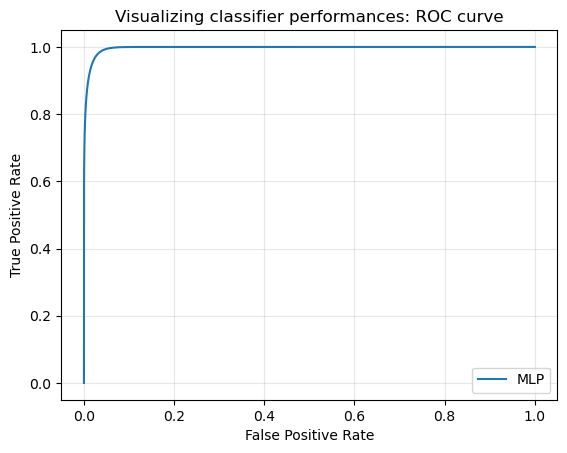

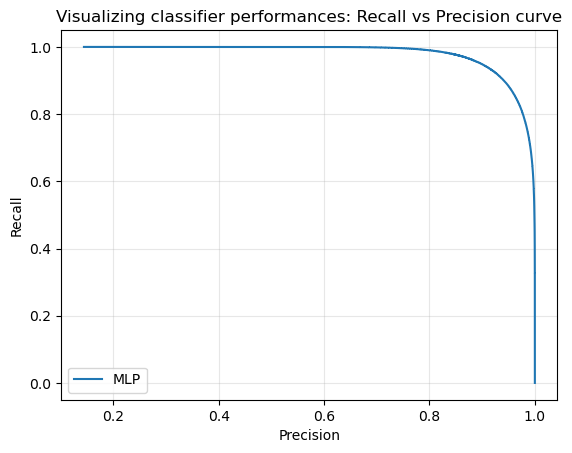

In [31]:
# Plotting performances
plt.plot(fpr_mlp, tpr_mlp, label="MLP")
plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
plt.close()

plt.plot(precision_mlp, recall_mlp, label="MLP")
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

In [32]:
report_dict = classification_report(y_test, y_pred_mlp, output_dict=True)
accuracy = report_dict.pop('accuracy')
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.round(5)
print(f"Accuracy: {accuracy:.5f}")

Accuracy: 0.97800


In [33]:
df_report

,precision,recall,f1-score,support
0.0,0.98581,0.98852,0.98716,5134533.0
1.0,0.93079,0.91557,0.92311,865467.0
macro avg,0.95830,0.95205,0.95514,6000000.0
weighted avg,0.97787,0.97800,0.97792,6000000.0


#### PyTorch

In [62]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [63]:
# You can downsample the data for debugging purposes
sel_table = table.sample(int(1e5), random_state=42)

In [64]:
feature_table = sel_table.drop(columns=['snr', 'det'])

In [65]:
# Formatting data with the sklearn style
X = np.array(feature_table.values)
X_names = np.array(feature_table.columns)
y = np.array(sel_table['det'].values)

In [66]:
print(X_names)
print(X.shape)
print(y.shape)

['chi1x' 'chi1y' 'chi1z' 'chi2x' 'chi2y' 'chi2z' 'dec' 'iota' 'mtot' 'psi'
 'q' 'ra' 'z']
(100000, 13)
(100000,)


In [67]:
# Split the dataset in tranining + test dataset
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(X, y, range(len(X)), test_size=0.3, random_state=42)

In [68]:
# Normalizing data
scaler = StandardScaler()
X_std_train = scaler.fit_transform(X_train)
X_std_test = scaler.transform(X_test)

In [69]:
print(X_std_train.shape)
print(y_train.shape)
print(X_std_test.shape)
print(y_test.shape)

(70000, 13)
(70000,)
(30000, 13)
(30000,)


In [70]:
# Now convert datasets into PyTorch tensors
X_train_tensor = torch.tensor(X_std_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor = torch.tensor(X_std_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [71]:
# Loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [72]:
# The autoencoder learns to reconstruct inputs and produce compressed latent features
class Autoencoder(nn.Module):
    def __init__(self, input_dim=13, latent_dim=7):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 10),
            nn.ReLU(),
            nn.Linear(10, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [73]:
autoencoder = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.01, weight_decay=0.01)

for epoch in range(200):
    autoencoder.train()
    total_loss = 0
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)
        optimizer.zero_grad()
        recon = autoencoder(X_batch)
        loss = criterion(recon, X_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if(epoch%10==0):
        print(f"Epoch [{epoch+1}/200] - AE Loss: {total_loss/len(train_loader):.6f}")

Epoch [1/200] - AE Loss: 0.705869
Epoch [11/200] - AE Loss: 0.482475
Epoch [21/200] - AE Loss: 0.482270
Epoch [31/200] - AE Loss: 0.482417
Epoch [41/200] - AE Loss: 0.481994
Epoch [51/200] - AE Loss: 0.482184
Epoch [61/200] - AE Loss: 0.482290
Epoch [71/200] - AE Loss: 0.482150
Epoch [81/200] - AE Loss: 0.482186
Epoch [91/200] - AE Loss: 0.482213
Epoch [101/200] - AE Loss: 0.482220
Epoch [111/200] - AE Loss: 0.482362
Epoch [121/200] - AE Loss: 0.482338
Epoch [131/200] - AE Loss: 0.482443
Epoch [141/200] - AE Loss: 0.482700
Epoch [151/200] - AE Loss: 0.482448
Epoch [161/200] - AE Loss: 0.482274
Epoch [171/200] - AE Loss: 0.482445
Epoch [181/200] - AE Loss: 0.482203
Epoch [191/200] - AE Loss: 0.482420


In [74]:
autoencoder.eval()
with torch.no_grad():
    X_train_latent = autoencoder.encoder(X_train_tensor.to(device)).cpu()
    X_test_latent  = autoencoder.encoder(X_test_tensor.to(device)).cpu()

In [75]:
print(X_train_latent.shape)
print(X_test_latent.shape)

torch.Size([70000, 7])
torch.Size([30000, 7])


In [76]:
# Now train a fully-connected neural network (a MLP) with the reduced dataset
class MLP(nn.Module):
    def __init__(self, input_dim=7):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)  # 2 logit → CrossEntropyLoss
        )

    def forward(self, x):
        return self.net(x)

In [77]:
mlp_torch = MLP().to(device)
criterion_mlp = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp_torch.parameters(), lr=0.01, weight_decay=0.01)

train_latent_loader = DataLoader(TensorDataset(X_train_latent, y_train_tensor), batch_size=128, shuffle=True)

for epoch in range(200):
    mlp_torch.train()
    total_loss_mlp = 0
    for X_batch, y_batch in train_latent_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_mlp.zero_grad()
        outputs_mlp = mlp_torch(X_batch)
        loss_mlp = criterion_mlp(outputs_mlp, y_batch)
        loss_mlp.backward()
        optimizer_mlp.step()
        total_loss_mlp += loss_mlp.item()
    if(epoch%10==0):
        print(f"Epoch [{epoch+1}/200] - MLP Loss: {total_loss_mlp/len(train_latent_loader):.4f}")

Epoch [1/200] - MLP Loss: 0.1939
Epoch [11/200] - MLP Loss: 0.1724
Epoch [21/200] - MLP Loss: 0.1713
Epoch [31/200] - MLP Loss: 0.1718
Epoch [41/200] - MLP Loss: 0.1718
Epoch [51/200] - MLP Loss: 0.1730
Epoch [61/200] - MLP Loss: 0.1724
Epoch [71/200] - MLP Loss: 0.1719
Epoch [81/200] - MLP Loss: 0.1739
Epoch [91/200] - MLP Loss: 0.1709
Epoch [101/200] - MLP Loss: 0.1715
Epoch [111/200] - MLP Loss: 0.1720
Epoch [121/200] - MLP Loss: 0.1727
Epoch [131/200] - MLP Loss: 0.1730
Epoch [141/200] - MLP Loss: 0.1720
Epoch [151/200] - MLP Loss: 0.1733
Epoch [161/200] - MLP Loss: 0.1732
Epoch [171/200] - MLP Loss: 0.1714
Epoch [181/200] - MLP Loss: 0.1730
Epoch [191/200] - MLP Loss: 0.1707


In [78]:
mlp_torch.eval()
with torch.no_grad():
    outs = mlp_torch(X_test_latent.to(device))
    preds = torch.argmax(outs, dim=1).cpu()
    probs = torch.softmax(outs, dim=1)[:, 1].cpu()

# Convert to numpy
y_true_torch = y_test_tensor.cpu().numpy()
y_pred_torch = preds.numpy()
y_prob_torch = probs.numpy()

# Metrics
acc = accuracy_score(y_true_torch, y_pred_torch)
prec = precision_score(y_true_torch, y_pred_torch)
rec = recall_score(y_true_torch, y_pred_torch)
cont = 1 - prec

# Print results
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"Contamination: {cont:.3f}")
print("\nClassification Report:\n", classification_report(y_true_torch, y_pred_torch, digits=3))

Accuracy:  0.928
Precision: 0.705
Recall:    0.861
Contamination: 0.295

Classification Report:
               precision    recall  f1-score   support

           0      0.976     0.939     0.957     25668
           1      0.705     0.861     0.776      4332

    accuracy                          0.928     30000
   macro avg      0.841     0.900     0.866     30000
weighted avg      0.937     0.928     0.931     30000



In [80]:
fpr_mlp, tpr_mlp, thresh1_mlp = roc_curve(y_true_torch, y_prob_torch)
precision_mlp, recall_mlp, thresh2_mlp = precision_recall_curve(y_true_torch, y_prob_torch)

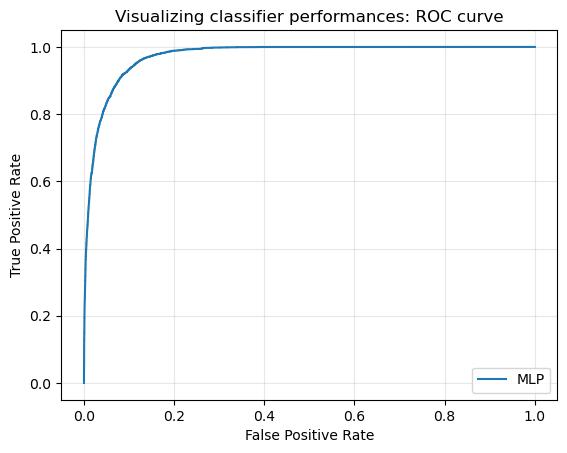

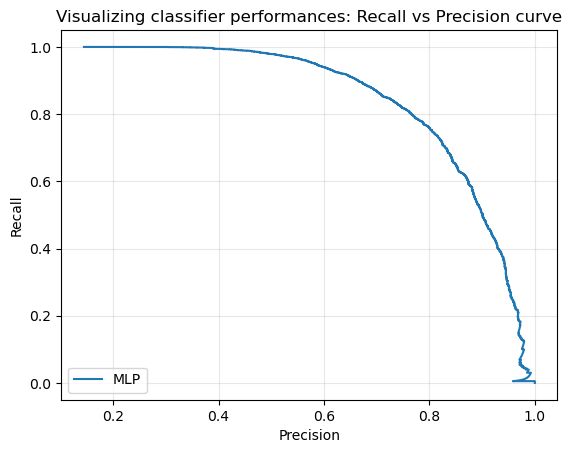

In [81]:
# Plotting performances
plt.plot(fpr_mlp, tpr_mlp, label="MLP")
plt.title("Visualizing classifier performances: ROC curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
plt.close()

plt.plot(precision_mlp, recall_mlp, label="MLP")
plt.title("Visualizing classifier performances: Recall vs Precision curve")
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

Reducing the dimensionality of the dataset doesn't seem to bring big improvements for the classification task

In [91]:
# Convert to numpy for some visualization
X_torch = X_test_latent.cpu().numpy()

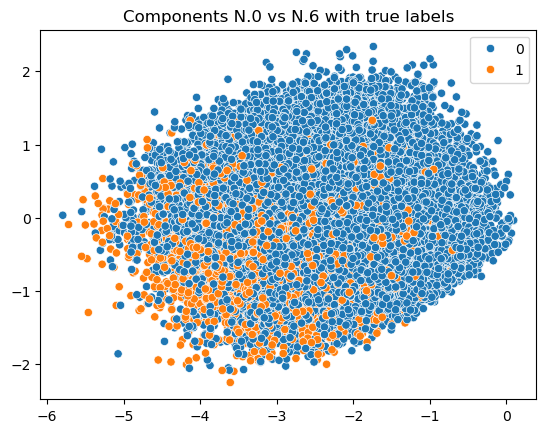

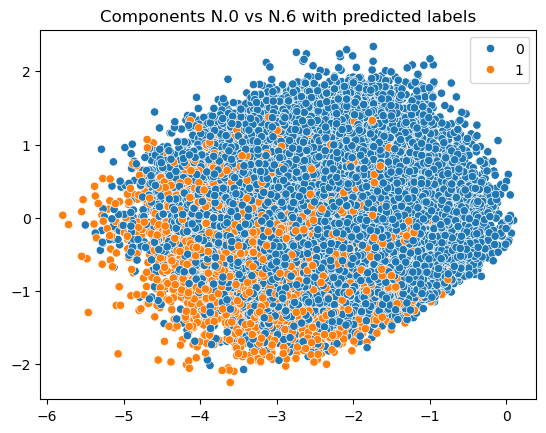

In [92]:
i, j = np.random.choice(range(7), 2, replace=False)
sns.scatterplot(x=X_torch[:, i], y=X_torch[:, j], hue=y_true_torch)
plt.title(f"Components N.{i} vs N.{j} with true labels")
plt.show()
plt.close()
sns.scatterplot(x=X_torch[:, i], y=X_torch[:, j], hue=y_pred_torch)
plt.title(f"Components N.{i} vs N.{j} with predicted labels")
plt.show()

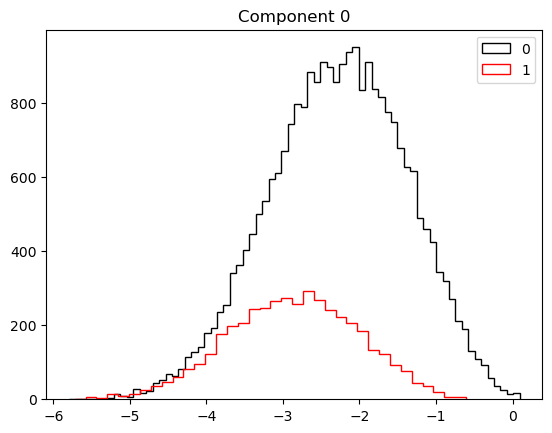

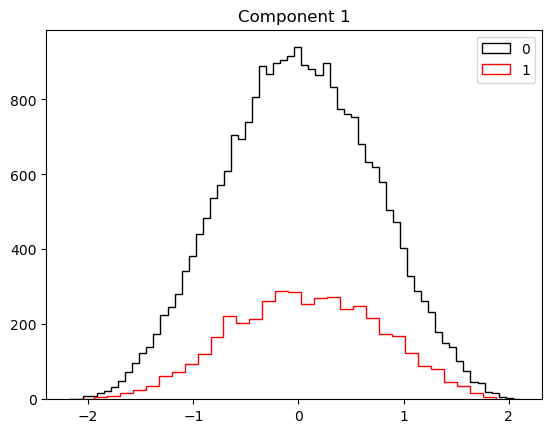

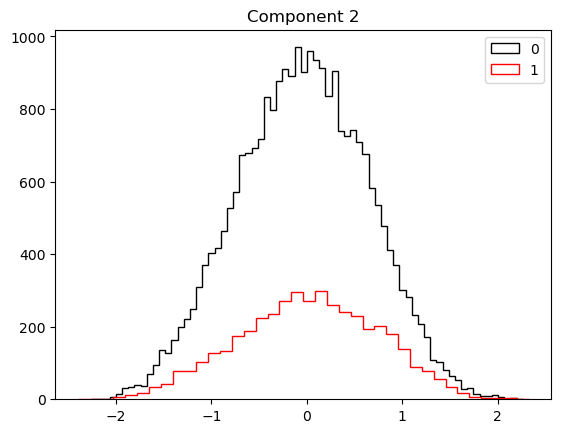

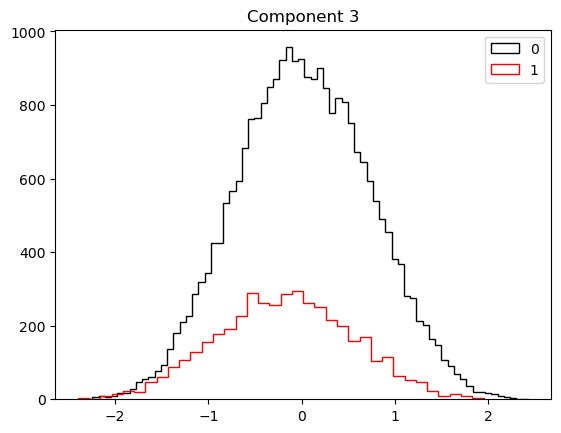

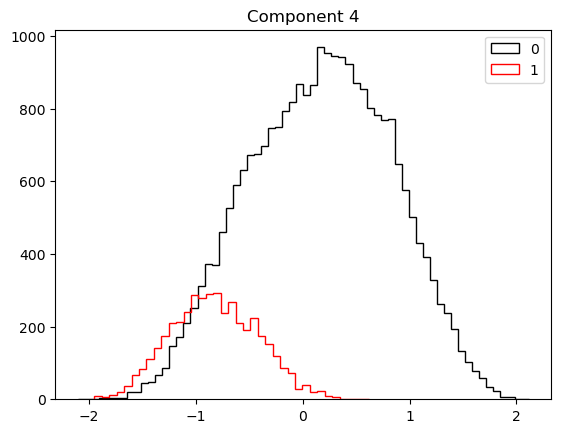

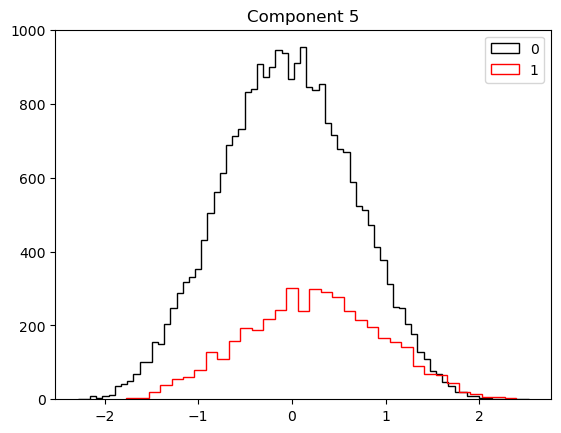

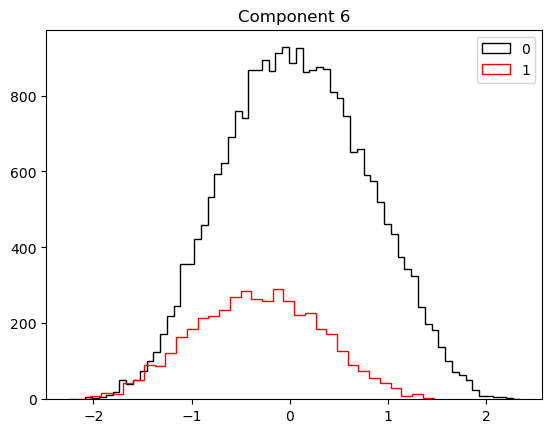

In [93]:
for i in range(7):
  plt.hist(X_torch[:, i].flatten()[y_true_torch==0], bins="auto", histtype='step', color='black', label="0")
  plt.hist(X_torch[:, i].flatten()[y_true_torch==1], bins="auto", histtype='step', color='red', label="1")
  plt.legend()
  plt.title(f"Component {i}")
  plt.show()
  plt.close()

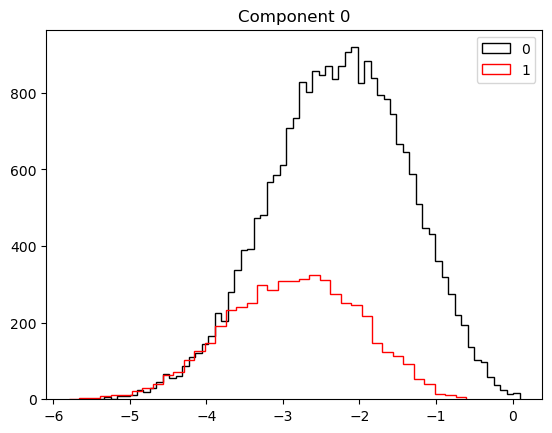

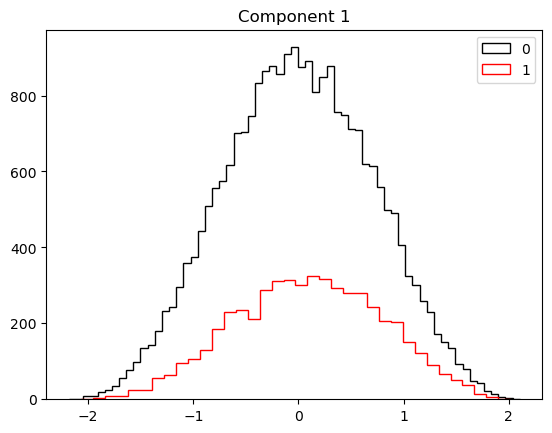

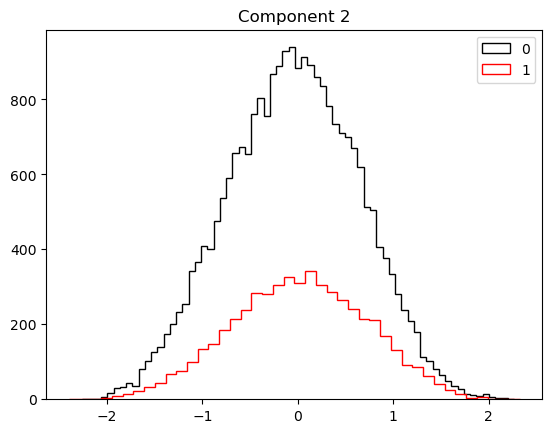

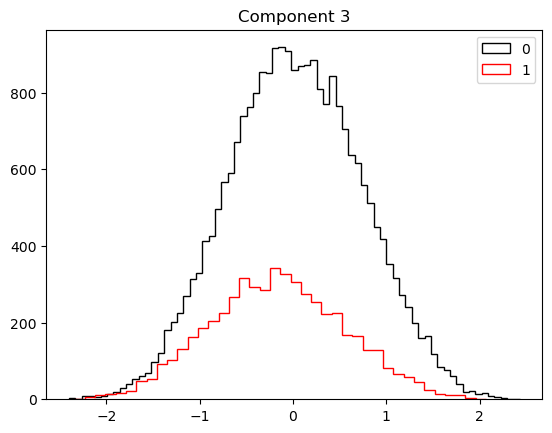

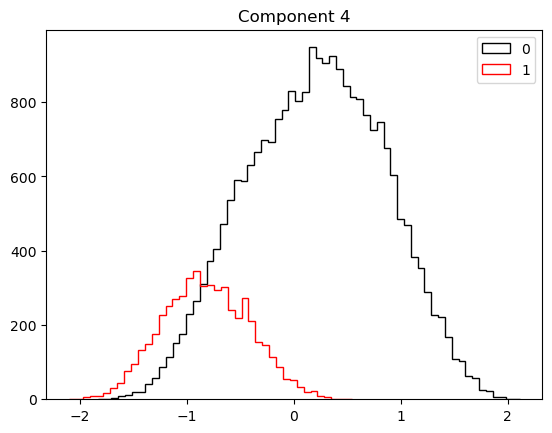

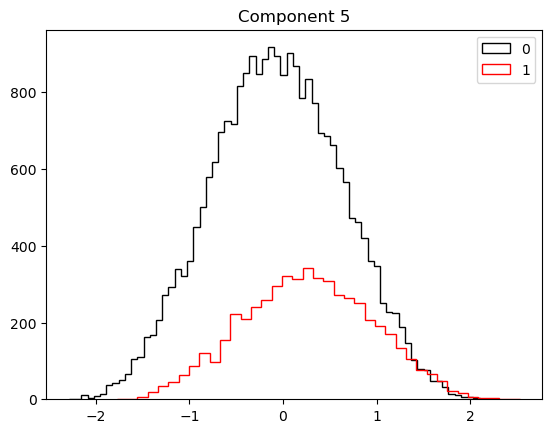

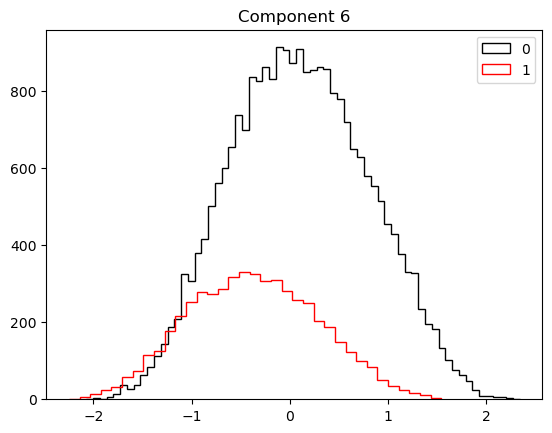

In [94]:
for i in range(7):
  plt.hist(X_torch[:, i].flatten()[y_pred_torch==0], bins="auto", histtype='step', color='black', label="0")
  plt.hist(X_torch[:, i].flatten()[y_pred_torch==1], bins="auto", histtype='step', color='red', label="1")
  plt.legend()
  plt.title(f"Component {i}")
  plt.show()
  plt.close()